# COPY OF LoRA-based mBART50 Fine-tuning for Tagalog Dataset
## ⚠️⚠️ Rank -> 16, Alpha -> 32, Fast Learning Rate (1e-4), 10 Epochs ⚠️⚠️

Uncomment before running.

In [1]:
# !pip uninstall torch -y
# !pip install --pre torch==2.9.0.dev20250803+cu128 --index-url https://download.pytorch.org/whl/nightly/cu128
# !pip install transformers sacrebleu
#!pip install --upgrade peft  
# !pip install datasets
# !pip install --upgrade transformers accelerate

In [2]:
#!pip install tiktoken sentencepiece
#!pip install matplotlib
# !pip install evaluate

For saving the checkpoints

In [3]:
ckpts_path = "./ckpts"

In [4]:
import torch

def _check_gpu():
    if torch.cuda.is_available():
        print(f"GPU is available: {torch.cuda.get_device_name(0)}")
    else:
        print("GPU not available, using CPU.")
    return torch.cuda.is_available()

use_gpu = _check_gpu()

GPU is available: NVIDIA GeForce RTX 5070


In [5]:
torch.manual_seed(42)
if use_gpu:
    torch.cuda.manual_seed_all(42)

TOKENIZERS_PARALLELISM = False

# Data Preprocessing

In [6]:
from datasets import load_dataset, Dataset, DatasetDict, Value

# Define the data files
data_files = {
    "train": {
        "tl": "../corpus-parallel-txt/train.tl.cleaned",
        "en": "../corpus-parallel-txt/train.en.cleaned"
    },
    "validation": {
        "tl": "../corpus-parallel-txt/val.tl.cleaned",
        "en": "../corpus-parallel-txt/val.en.cleaned"
    },
    # "test": {
    #     "tl": "../corpus-parallel-txt/test.tl",
    #     "en": "../corpus-parallel-txt/test.en"
    # }
}

dataset_dict = DatasetDict()

for split_name in data_files:
    # Read source and target files
    with open(data_files[split_name]["tl"], "r", encoding="utf-8") as f_src:
        src_texts = [line.strip() for line in f_src.readlines()]
    
    with open(data_files[split_name]["en"], "r", encoding="utf-8") as f_tgt:
        tgt_texts = [line.strip() for line in f_tgt.readlines()]
    
    # Create dataset with parallel texts
    dataset_dict[split_name] = Dataset.from_dict({
        "tl": src_texts,
        "en": tgt_texts
    })

data = dataset_dict

c:\Users\Reejay Salinas\Downloads\SalinTala\Moodeng-MT\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
data

DatasetDict({
    train: Dataset({
        features: ['tl', 'en'],
        num_rows: 2801
    })
    validation: Dataset({
        features: ['tl', 'en'],
        num_rows: 701
    })
})

In [8]:
# get 1 record
data["validation"][525]

{'tl': 'lamok lang talaga aq guys pag kasama ko sila huhu',
 'en': '"I\'m really just a mosquito, guys, when I\'m with them, huhu."'}

# Tokenization

In [9]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

SRC_LANG = "tl_XX"
TGT_LANG = "en_XX"

tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50-many-to-many-mmt", use_fast=False)
model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")

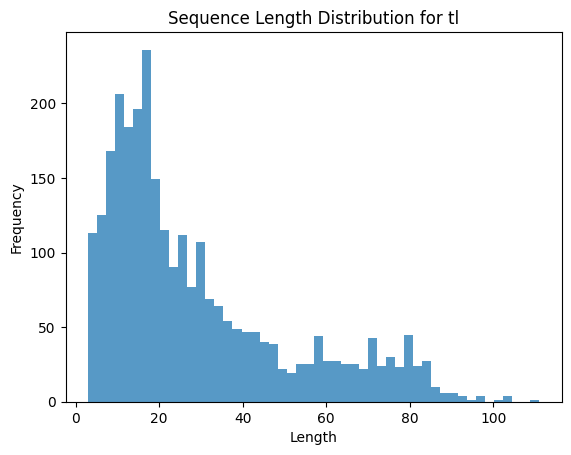

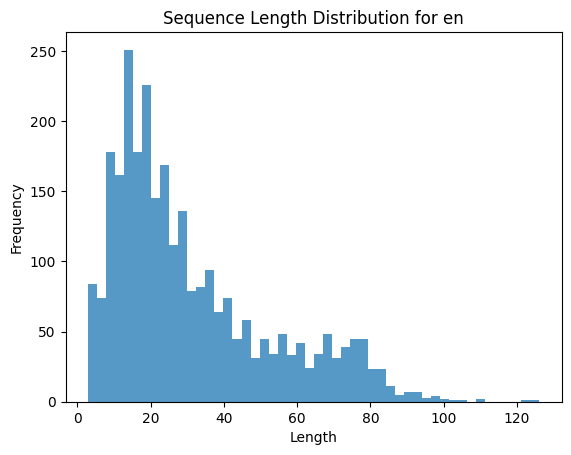

In [10]:
# Check max sequence length in the dataset
import matplotlib.pyplot as plt
import numpy as np

def plot_seq_length_distrib(data, language_key, tokenizer):
    lengths = [len(tokenizer.encode(example[language_key])) for example in data]
    plt.hist(lengths, bins=50, alpha=0.75)
    plt.title(f"Sequence Length Distribution for {language_key}")
    plt.xlabel("Length")
    plt.ylabel("Frequency")
    plt.show()
    return lengths

src_lengths = plot_seq_length_distrib(data["train"], "tl", tokenizer)
tgt_lengths = plot_seq_length_distrib(data["train"], "en", tokenizer)

In [11]:
def preprocess(examples):
    inputs = [ex for ex in examples["tl"]]
    targets = [ex for ex in examples["en"]]

    tokenizer.src_lang = SRC_LANG
    tokenizer.tgt_lang = TGT_LANG

    model_inputs = tokenizer(inputs, max_length=128, truncation=True, padding="max_length")

    # Setup the tokenizer for targets
    with tokenizer.as_target_tokenizer():
        labels = tokenizer(targets, max_length=128, truncation=True, padding="max_length")

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

In [12]:
train_ds = data["train"].map(preprocess, batched=True)
val_ds = data["validation"].map(preprocess, batched=True)
# test_ds = data["test"].map(preprocess, batched=True)

Map:   0%|          | 0/2801 [00:00<?, ? examples/s]c:\Users\Reejay Salinas\Downloads\SalinTala\Moodeng-MT\.venv\Lib\site-packages\transformers\tokenization_utils_base.py:4007: UserWarning: `as_target_tokenizer` is deprecated and will be removed in v5 of Transformers. You can tokenize your labels by using the argument `text_target` of the regular `__call__` method (either in the same call as your input texts if you use the same keyword arguments, or in a separate call.
  warnings.warn(
Map: 100%|██████████| 701/701 [00:00<00:00, 5736.41 examples/s]


In [13]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=["q_proj", "v_proj", "k_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="SEQ_2_SEQ_LM"
)

In [14]:
model_lora = get_peft_model(model, lora_config)

model_lora.print_trainable_parameters()

trainable params: 3,538,944 || all params: 614,418,432 || trainable%: 0.5760


In [15]:
from accelerate import Accelerator, DataLoaderConfiguration

dataloader_config = DataLoaderConfiguration(
    dispatch_batches=False,
    split_batches=True
)

accelerator = Accelerator(dataloader_config=dataloader_config)

In [16]:
from transformers import Seq2SeqTrainingArguments
import os

# Ensure a single canonical logs directory at repo root
LOG_DIR = os.path.abspath(os.path.join('..', 'training_logs'))
os.makedirs(LOG_DIR, exist_ok=True)

training_args = Seq2SeqTrainingArguments(
    output_dir="./mbart-lora-finetuned",
    eval_strategy='epoch',
    learning_rate=1e-4,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    save_steps=500,
    save_strategy="steps",
    num_train_epochs=10,
    predict_with_generate=True,
    fp16=True if use_gpu else False,
    logging_dir=LOG_DIR,
    logging_steps=10,
    logging_strategy="steps",
    report_to="none",
)

In [17]:
# File-based logging callback and BLEU compute for Trainer
from transformers import TrainerCallback
import os
import datetime as dt
import numpy as np

# Create a timestamped log file path in the canonical log directory
_timestamp = dt.datetime.now().strftime("%Y%m%d_%H%M%S")
LOG_FILE_PATH = os.path.join(LOG_DIR, f"training_{_timestamp}.log")

class FileLoggerCallback(TrainerCallback):
    def __init__(self, log_path: str):
        self.log_path = log_path
        self.last_train_loss = None

    def _write(self, line: str):
        with open(self.log_path, 'a', encoding='utf-8') as f:
            f.write(line + "\n")

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs is None:
            return
        ts = dt.datetime.now().strftime("%Y-%m-%d %H:%M:%S")
        # Track latest training loss
        if 'loss' in logs:
            try:
                self.last_train_loss = float(logs['loss'])
            except Exception:
                self.last_train_loss = None
        # When evaluation logs appear, commit a triple: train_loss, val_loss, bleu
        if 'eval_loss' in logs:
            try:
                val_loss = float(logs['eval_loss'])
            except Exception:
                val_loss = float('nan')
            bleu_val = None
            # Transformers prefixes eval metrics with 'eval_'
            if 'eval_bleu' in logs:
                try:
                    bleu_val = float(logs['eval_bleu'])
                except Exception:
                    bleu_val = None
            # Write lines that match the parser regex
            if self.last_train_loss is not None:
                self._write(f"{ts} INFO train_loss={self.last_train_loss:.4f}")
            else:
                self._write(f"{ts} INFO train_loss={float('nan')}")
            self._write(f"{ts} INFO val_loss={val_loss:.4f}")
            if bleu_val is not None and np.isfinite(bleu_val):
                # Format BLEU with 2 decimals to match \d+\.\d+
                self._write(f"{ts} INFO bleu={bleu_val:.2f}")
            # Reset after commit
            self.last_train_loss = None

# compute_metrics for Seq2Seq to produce BLEU during evaluation
from typing import Dict

def compute_metrics(eval_pred) -> Dict[str, float]:
    preds, labels = eval_pred
    if isinstance(preds, tuple):
        preds = preds[0]
    # Replace -100 (ignore index) with pad token id for decoding
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    try:
        import sacrebleu
        bleu = sacrebleu.corpus_bleu(decoded_preds, [decoded_labels]).score
    except Exception:
        bleu = float('nan')
    return {"bleu": float(bleu)}



In [18]:
from transformers import Seq2SeqTrainer, DataCollatorForSeq2Seq

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model_lora)

# Instantiate file logger callback
file_logger_cb = FileLoggerCallback(LOG_FILE_PATH)

trainer = Seq2SeqTrainer(
    model=model_lora,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[file_logger_cb],
)

C:\Users\Reejay Salinas\AppData\Local\Temp\ipykernel_30996\2851897586.py:8: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Seq2SeqTrainer.__init__`. Use `processing_class` instead.
  trainer = Seq2SeqTrainer(


# Training with LoRA

In [19]:
trainer.train()
#trainer.train(resume_from_checkpoint=ckpts_path if ckpts_path else None)

Epoch,Training Loss,Validation Loss,Bleu
1,8.237500,8.587488,24.487590
2,8.494800,8.544477,26.219091
3,8.073600,8.522670,27.800527
4,8.175700,8.504287,28.771639
5,8.191000,8.502899,28.912786
6,8.032000,8.492990,29.456783
7,8.243500,8.491599,29.722442
8,8.750200,8.487456,29.854808
9,8.086200,8.487124,29.753587
10,8.484200,8.485717,29.993386


TrainOutput(global_step=3510, training_loss=8.370820345973696, metrics={'train_runtime': 2334.9476, 'train_samples_per_second': 11.996, 'train_steps_per_second': 1.503, 'total_flos': 7663791730851840.0, 'train_loss': 8.370820345973696, 'epoch': 10.0})

In [20]:
model_lora.save_pretrained("./mbart-lora-finetuned/epoch-10-fast-learning-rate")
tokenizer.save_pretrained("./mbart-lora-finetuned/epoch-10-fast-learning-rate")

('./mbart-lora-finetuned/epoch-10-fast-learning-rate\\tokenizer_config.json',
 './mbart-lora-finetuned/epoch-10-fast-learning-rate\\special_tokens_map.json',
 './mbart-lora-finetuned/epoch-10-fast-learning-rate\\sentencepiece.bpe.model',
 './mbart-lora-finetuned/epoch-10-fast-learning-rate\\added_tokens.json')

# Evaluation + Inference

In [ ]:
import torch

In [21]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import PeftModel, PeftConfig

tokenizer = AutoTokenizer.from_pretrained("./mbart-lora-finetuned/epoch-10-fast-learning-rate")

config = PeftConfig.from_pretrained("./mbart-lora-finetuned/epoch-10-fast-learning-rate")
model = AutoModelForSeq2SeqLM.from_pretrained(config.base_model_name_or_path)
model = PeftModel.from_pretrained(model, "./mbart-lora-finetuned/epoch-10-fast-learning-rate")

model.eval()

SRC_LANG = "tl_XX"
TGT_LANG = "en_XX"

tokenizer.src_lang = SRC_LANG
tokenizer.tgt_lang = TGT_LANG

model.config.forced_bos_token_id = tokenizer.lang_code_to_id[TGT_LANG]

In [22]:
def translate(tl_txt, model):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # TODO: Need to pre-process (clean, normalize) input text katulad nung sa .csv file niyo.
    inputs = tokenizer(tl_txt, return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
    
    model.eval()

    with torch.no_grad():
        translated_tokens = model.generate(**inputs, max_length=128, num_beams=4, early_stopping=True)
        translated_texts = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
    return translated_texts

In [23]:
fil_txt = "Oh, kumusta ka na?"
eng_txt = translate(fil_txt, model)
print(f"FIL: {fil_txt}")
print(f"ENG: {eng_txt[0]}")

c:\Users\Reejay Salinas\Downloads\SalinTala\Moodeng-MT\.venv\Lib\site-packages\transformers\generation\utils.py:1715: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed in v5. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


FIL: Oh, kumusta ka na?
ENG: "Oh, are you stupid?"


In [24]:
import evaluate
import numpy as np
import torch
from tqdm.auto import tqdm

def eval_model(model, tokenizer, test_ds, batch_size=8, max_samples=None):
    bleu = evaluate.load("bleu")
    sacrebleu = evaluate.load("sacrebleu")

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    tokenizer.src_lang = SRC_LANG
    tokenizer.tgt_lang = TGT_LANG

    model.config.forced_bos_token_id = tokenizer.lang_code_to_id[TGT_LANG]

    if max_samples is not None:
        test_ds = test_ds.select(range(max_samples))

    all_preds = []
    all_labels = []

    for i in tqdm(range(0, len(test_ds), batch_size)):
        batch = test_ds[i:i+batch_size]
        inputs = tokenizer(batch["tl"], return_tensors="pt", padding=True, truncation=True, max_length=128).to(device)
        labels = batch["en"]

        with torch.no_grad():
            translated_tokens = model.generate(**inputs, max_length=128, num_beams=4, early_stopping=True)
            translated_texts = tokenizer.batch_decode(translated_tokens, skip_special_tokens=True)
        
        all_preds.extend(translated_texts)
        all_labels.extend(labels)

    bleu_score = bleu.compute(predictions=all_preds, references=[[label] for label in all_labels])["bleu"]
    sacrebleu_score = sacrebleu.compute(predictions=all_preds, references=[[label] for label in all_labels])["score"]

    return bleu_score, sacrebleu_score

In [25]:
results = eval_model(model, tokenizer, val_ds, batch_size=8, max_samples=500)
print(f"BLEU: {results[0]:.2f}")
print(f"SacreBLEU: {results[1]:.2f}")

100%|██████████| 63/63 [01:31<00:00,  1.45s/it]

BLEU: 0.31
SacreBLEU: 31.24


In [ ]:
# Config from model_training_enhanced.py

# lora_config = LoraConfig(
#     r=64,
#     lora_alpha=128,
#     target_modules=["q_proj", "v_proj", "k_proj", "o_proj", "fc1", "fc2"],
#     lora_dropout=0.1,
#     bias="none",
#     task_type="SEQ_2_SEQ_LM"
# )

# training_args = Seq2SeqTrainingArguments(
#     output_dir="./mbart-lora-finetuned",
#     eval_strategy='epoch',
#     learning_rate=5e-5,
#     per_device_train_batch_size=2,
#     per_device_eval_batch_size=2,
#     weight_decay=0.01,
#     save_total_limit=3,
#     save_steps=500,
#     save_strategy="steps",
#     num_train_epochs=20,
#     predict_with_generate=True,
#     fp16=True if use_gpu else False,
#     logging_dir="./logs",
#     logging_steps=10,
#     gradient_accumulation_steps=4,
#     lr_scheduler_type="cosine",
#     warmup_ratio=0.1,
# )

In [ ]:
fil_txt = "Nakakainis ka today."
eng_txt = translate(fil_txt, model)
print(f"FIL: {fil_txt}")
print(f"ENG: {eng_txt[0]}")

FIL: Nakakainis ka today.
ENG: You're sleepy today.


In [ ]:
base_tokenizer = AutoTokenizer.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
base_model = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")

base_tokenizer.src_lang = SRC_LANG
base_tokenizer.tgt_lang = TGT_LANG
base_model.config.forced_bos_token_id = base_tokenizer.lang_code_to_id[TGT_LANG]

print("Evaluating base mBART50 model...")
base_results = eval_model(base_model, base_tokenizer, val_ds, batch_size=8)
print(f"Base mBART50 BLEU: {base_results[0]*100:.2f}")
print(f"Base mBART50 SacreBLEU: {base_results[1]:.2f}")

print("\nEvaluating your fine-tuned model...")
finetuned_results = eval_model(model, tokenizer, val_ds, batch_size=8)
print(f"Fine-tuned BLEU: {finetuned_results[0]*100:.2f}")
print(f"Fine-tuned SacreBLEU: {finetuned_results[1]:.2f}")

print(f"\nImprovement:")
print(f"BLEU: +{(finetuned_results[0] - base_results[0])*100:.2f} points")
print(f"SacreBLEU: +{finetuned_results[1] - base_results[1]:.2f} points")

Evaluating base mBART50 model...


100%|██████████| 88/88 [02:37<00:00,  1.79s/it]


Base mBART50 BLEU: 5.57
Base mBART50 SacreBLEU: 5.57

Evaluating your fine-tuned model...


100%|██████████| 88/88 [02:01<00:00,  1.38s/it]

Fine-tuned BLEU: 29.18
Fine-tuned SacreBLEU: 29.18

Improvement:
BLEU: +23.61 points
SacreBLEU: +23.61 points


In [26]:
# Load latest training metrics from log
import os, re, glob
import pandas as pd
import matplotlib.pyplot as plt


def get_latest_log_path(log_dir: str) -> str:
    log_paths = glob.glob(os.path.join(log_dir, "*.log"))
    if not log_paths:
        raise FileNotFoundError(f"No .log files found in {log_dir}.")
    return max(log_paths, key=os.path.getmtime)


def load_metrics_from_log(log_path: str) -> pd.DataFrame:
    train_pat = re.compile(r"train_loss=([+-]?\d+(?:\.\d+)?)")
    val_pat = re.compile(r"val_loss=([+-]?\d+(?:\.\d+)?)")
    bleu_pat = re.compile(r"bleu=([+-]?\d+(?:\.\d+)?)")
    last_train = None
    rows = []
    with open(log_path, "r", encoding="utf-8") as f:
        for raw in f:
            line = raw.strip()
            m_train = train_pat.search(line)
            if m_train:
                try:
                    last_train = float(m_train.group(1))
                except Exception:
                    last_train = None
                continue
            m_val = val_pat.search(line)
            if m_val:
                try:
                    val = float(m_val.group(1))
                except Exception:
                    val = float("nan")
                rows.append({
                    "train_loss": (float(last_train) if last_train is not None else float("nan")),
                    "val_loss": val,
                    "bleu": float("nan"),
                })
                continue
            m_bleu = bleu_pat.search(line)
            if m_bleu and rows:
                try:
                    rows[-1]["bleu"] = float(m_bleu.group(1))
                except Exception:
                    rows[-1]["bleu"] = float("nan")
                continue
    metrics = pd.DataFrame(rows)
    metrics["epoch"] = range(1, len(metrics) + 1)
    return metrics

LATEST_LOG = get_latest_log_path(LOG_DIR)
print(f"Using latest log: {os.path.basename(LATEST_LOG)}")

metrics = load_metrics_from_log(LATEST_LOG)
if metrics.empty:
    raise ValueError("Parsed 0 metric rows from the log. Ensure the FileLoggerCallback ran during eval.")
metrics.tail()


Using latest log: training_20250930_001308.log


,train_loss,val_loss,bleu,epoch
5,8.0320,8.4930,29.46,6
6,8.2435,8.4916,29.72,7
7,8.7502,8.4875,29.85,8
8,8.0862,8.4871,29.75,9
9,8.4842,8.4857,29.99,10


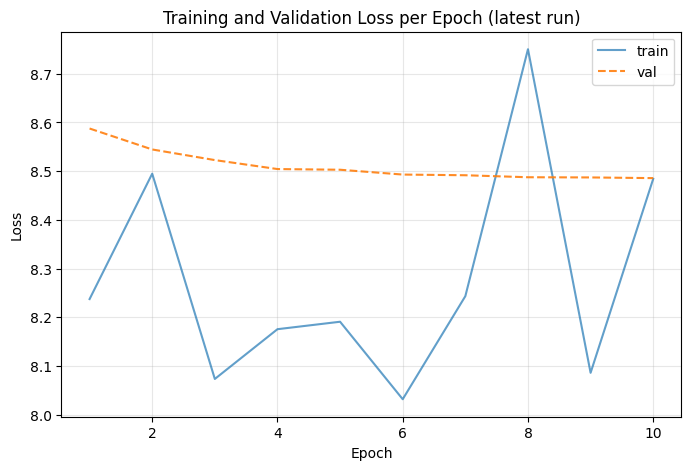

In [27]:
# Plot training and validation loss over epochs (latest log)
plt.figure(figsize=(8,5))
plt.plot(metrics['epoch'], metrics['train_loss'], label='train', alpha=0.7)
plt.plot(metrics['epoch'], metrics['val_loss'], label='val', linestyle='--', alpha=0.9)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss per Epoch (latest run)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.show()


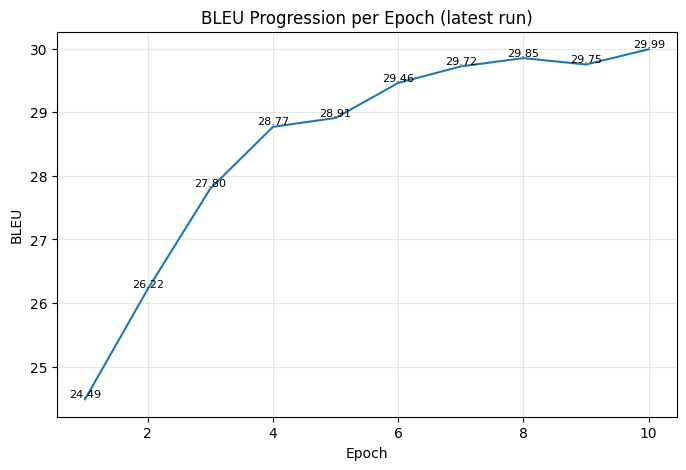

In [28]:
# Plot BLEU progression during training (latest log)
plt.figure(figsize=(8,5))
if 'bleu' in metrics.columns:
    plt.plot(metrics['epoch'], metrics['bleu'], label='BLEU', color='tab:blue')
    for x, y in zip(metrics['epoch'], metrics['bleu']):
        import pandas as _pd
        if _pd.notna(y):
            plt.text(x, y, f"{y:.2f}", ha='center', va='bottom', fontsize=8)
plt.xlabel('Epoch')
plt.ylabel('BLEU')
plt.title('BLEU Progression per Epoch (latest run)')
plt.grid(True, alpha=0.3)
plt.show()


In [ ]:
# Compare base vs fine-tuned BLEU on validation set
# Using the LoRA fine-tuned model from local directory
import os, time, torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import numpy as np

base_model_id = 'facebook/mbart-large-50-many-to-many-mmt'
lora_finetuned_dir = './mbart-lora-finetuned'  # Best model is in this directory

base_tok = AutoTokenizer.from_pretrained(base_model_id, use_fast=False)
base_mod = AutoModelForSeq2SeqLM.from_pretrained(base_model_id)

# Load LoRA fine-tuned model directly from local directory
ft_tok = AutoTokenizer.from_pretrained(lora_finetuned_dir, use_fast=False, local_files_only=True)
ft_mod = AutoModelForSeq2SeqLM.from_pretrained(lora_finetuned_dir, local_files_only=True)

In [ ]:
def evaluate_bleu_speed(model, tokenizer, src_texts, refs, src_lang='tl_XX', tgt_lang='en_XX', max_len=128, batch_size=16):  # Increased batch size
    tokenizer.src_lang = src_lang
    tokenizer.tgt_lang = tgt_lang

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = model.to(device)
    model.eval()

    preds = []
    t0 = time.time()
    
    # Use smaller subset for faster evaluation
    eval_src = src_texts[:30]  # Reduced from 200 to 50
    eval_ref = refs[:30]
    
    from tqdm import tqdm
    total_batches = (len(eval_src) + batch_size - 1) // batch_size
    
    for i in tqdm(range(0, len(eval_src), batch_size), desc="Generating translations", total=total_batches):
        batch = eval_src[i:i+batch_size]
        inputs = tokenizer(batch, return_tensors='pt', padding=True, truncation=True, max_length=max_len)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        with torch.no_grad():
            gen = model.generate(**inputs, max_length=max_len, num_beams=1)  # Use greedy search (beam=1) for speed
        decoded = tokenizer.batch_decode(gen, skip_special_tokens=True)
        preds.extend(decoded)
    elapsed = time.time() - t0
    sents_per_sec = len(eval_src) / elapsed if elapsed > 0 else float('inf')

    try:
        import sacrebleu
        bleu = sacrebleu.corpus_bleu(preds, [eval_ref]).score
    except Exception:
        bleu = float('nan')
    return bleu, elapsed, sents_per_sec

In [ ]:
# Prepare validation data
val_src = data['validation']['tl']
val_ref = data['validation']['en']

base_bleu, base_time, base_rate = evaluate_bleu_speed(base_mod, base_tok, val_src, val_ref)
ft_bleu, ft_time, ft_rate = evaluate_bleu_speed(ft_mod, ft_tok, val_src, val_ref)

print({'base_bleu': base_bleu, 'ft_bleu': ft_bleu})
print({'base_eval_time_s': base_time, 'ft_eval_time_s': ft_time})
print({'base_sents_per_sec': base_rate, 'ft_sents_per_sec': ft_rate})

Generating translations: 100%|██████████| 2/2 [00:52<00:00, 26.38s/it]

{'base_bleu': 4.532745830245339, 'ft_bleu': 34.921889492688614}
{'base_eval_time_s': 47.257851362228394, 'ft_eval_time_s': 52.76659440994263}
{'base_sents_per_sec': 0.6348151499748037, 'ft_sents_per_sec': 0.5685415239598485}


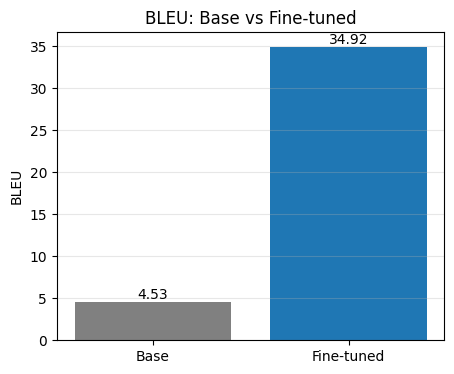

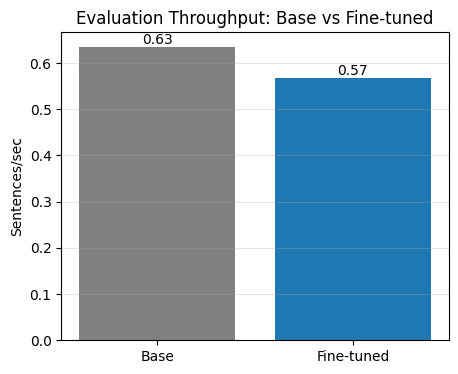

In [ ]:
# Bar charts for model comparison: BLEU and speed
labels = ['Base', 'Fine-tuned']
bleus = [base_bleu, ft_bleu]
rate = [base_rate, ft_rate]

def plot_bar(values, title, ylabel):
    plt.figure(figsize=(5,4))
    plt.bar(labels, values, color=['gray','tab:blue'])
    for i, v in enumerate(values):
        plt.text(i, v, f"{v:.2f}", ha='center', va='bottom')
    plt.title(title)
    plt.ylabel(ylabel)
    plt.grid(axis='y', alpha=0.3)
    plt.show()

plot_bar(bleus, 'BLEU: Base vs Fine-tuned', 'BLEU')
plot_bar(rate, 'Evaluation Throughput: Base vs Fine-tuned', 'Sentences/sec')